In [28]:
import pandas as pd
df = pd.read_csv('training_history.csv')

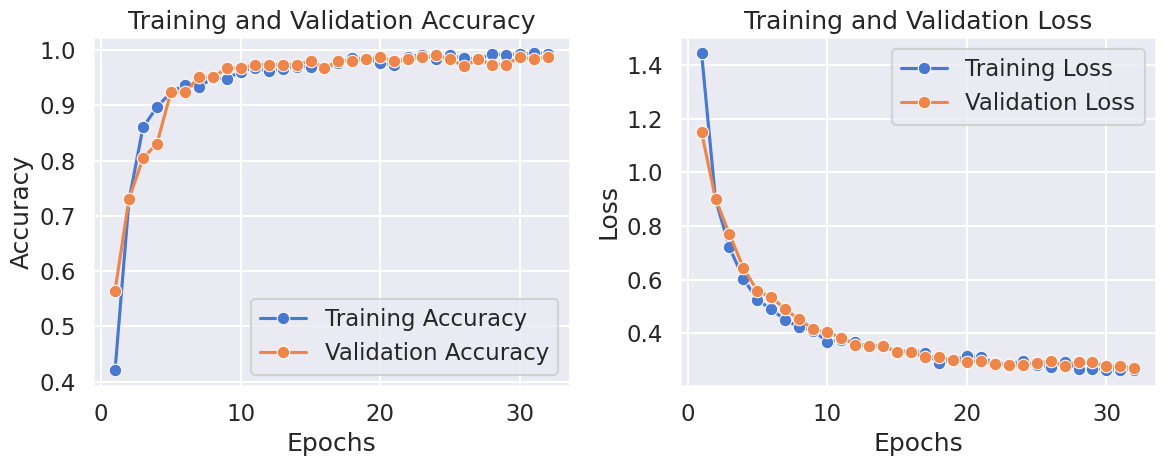

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid", context="talk", palette="muted")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.lineplot(x=df['epoch'], y=df['accuracy'], label='Training Accuracy', marker='o')
sns.lineplot(x=df['epoch'], y=df['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
sns.lineplot(x=df['epoch'], y=df['loss'], label='Training Loss', marker='o')
sns.lineplot(x=df['epoch'], y=df['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipython-input-30-1916533112.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=summary_df, palette=colors)


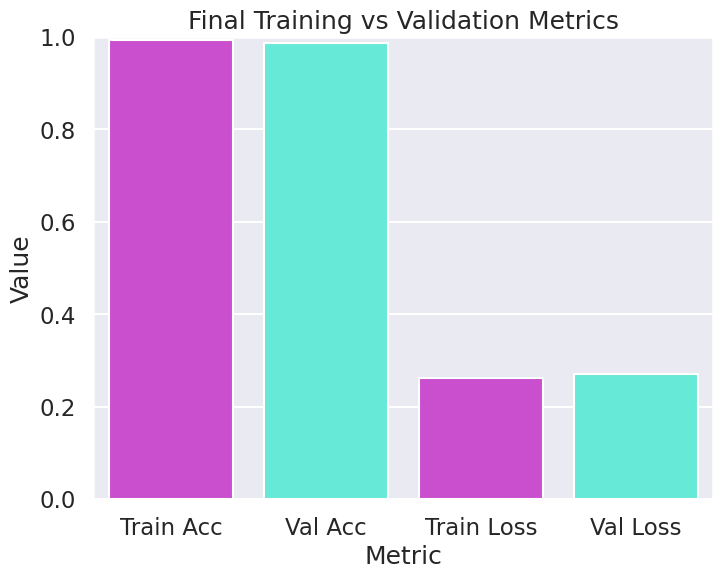

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

final_values = {
    'Metric': ['Train Acc', 'Val Acc', 'Train Loss', 'Val Loss'],
    'Value': [df['accuracy'].iloc[-1], df['val_accuracy'].iloc[-1],
              df['loss'].iloc[-1], df['val_loss'].iloc[-1]]
}
summary_df = pd.DataFrame(final_values)

colors = ['#de3ae3', '#52fee6', '#de3ae3', '#52fee6']

sns.set(style="darkgrid", context="talk")
plt.figure(figsize=(8, 6))
sns.barplot(x='Metric', y='Value', data=summary_df, palette=colors)
plt.title('Final Training vs Validation Metrics')
plt.ylim(0, 1)
plt.show()

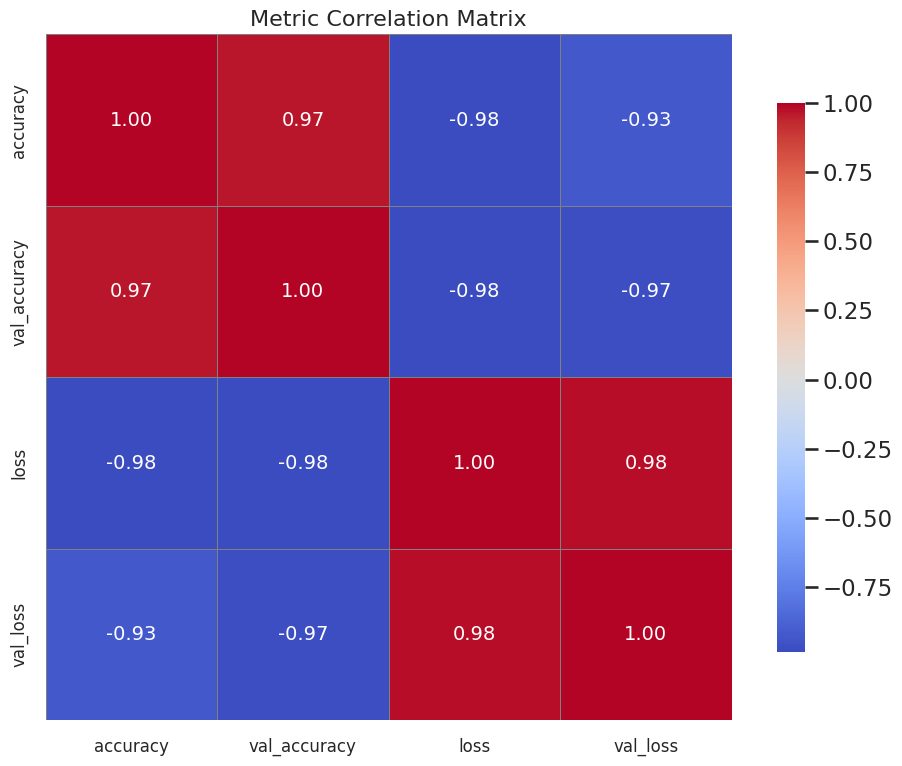

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.drop(columns=['epoch']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    annot_kws={"size": 14},
    cbar_kws={"shrink": 0.8},
    square=True,
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Metric Correlation Matrix', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


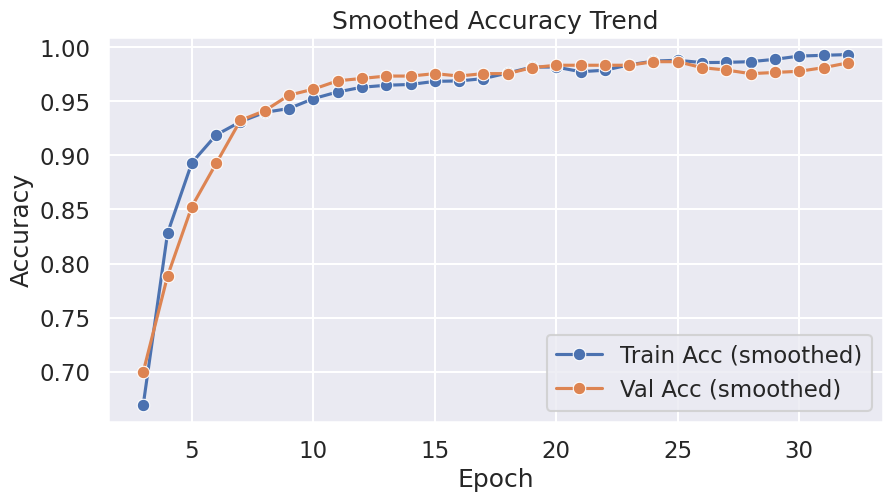

In [32]:
df['acc_smooth'] = df['accuracy'].rolling(3).mean()
df['val_acc_smooth'] = df['val_accuracy'].rolling(3).mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=df['epoch'], y=df['acc_smooth'], label='Train Acc (smoothed)', marker='o')
sns.lineplot(x=df['epoch'], y=df['val_acc_smooth'], label='Val Acc (smoothed)', marker='o')
plt.title('Smoothed Accuracy Trend')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()